1: the following were common warnings:

"NA values found in column .*"

"Setting cusom attributes on geometry objects is deprecated.*"

"STRtree will be changed in 2/.0/.0.*"

"the converter_dtype parameter is deprecated.*"

"DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
    EPOCH = datetime.datetime.utcfromtimestamp(0)"




2: the code runs fine but the generating csba step takes like 9 hours so it would be helpful to have an sh that lets you rerun the metrics code given an already created cbsa file

3: The reproduction results for Moran from the previous code give the following for when the x column is black vs poc respectively. The upward trend becomes a lot murkier (though the only difference between this and previous runs is that we are using counts instead of shares)

![Moran_Black](Moran_black.png)

![Moran_POC](Moran_POC.png)

4: The updated metrics passed 36 of the test_metrics.py tests (which is I think all of them) with two deprecation warnings about datetime: "DeprecationWarning: datetime.datetime.utcfromtimestamp()"

5: Some more deprecations I noticed:
generate_figures.py line 43, uses .set(), VSCode says it should be .set_theme() now

Parse output line eleven uses parse_raw() which seems to work but is apparently deprecated in favor of model_validate_json

7: The differences between the new and old half edge scores are barely perceptible. Below are outputs before and after updating the code respectively \( note that before washington registers as slightly more segregated than dallas in 1970 whereas they register as equally segregated after the code change\):

![before](before_white_black_august_2017_edge_lam_1_angle_1.png)
![after](after_white_black_august_2017_edge_lam_1_angle_1.png)

The paper mentions that setting lambda below 1 has a negligible effect so perhaps all the summations over the edges dominate the summations over nodes meaning that the overcountings roughly cancel out as in below

$skew(x,x)_{overcounted}=\frac{\Sigma_i x_i^2+2\Sigma_{j\sim i}(x_ix_j)^2}{\Sigma_i x_i^2+2\Sigma_{j\sim i}(x_ix_j)^2 + \Sigma_i x_i^2+2\Sigma_{j\sim i}(x_iy_j+y_ix_j)} \approx \frac{2\Sigma_{j\sim i}(x_ix_j)^2}{+2\Sigma_{j\sim i}(x_ix_j)^2 +2\Sigma_{j\sim i}(x_iy_j+y_ix_j)}=skew(x,x)$

One current explanation for why CAPY is resistant to the MAUP in a way that Moran isn't is that Moran is blind to the composition of units whereas CAPY counts in unit ties. If the number of in unit ties are so dominated by the adjacency ties I don't see how this explanation could account for the discrepancy

8: The overlaps.py function seems to create some errors in the 1970 data where you have single tract islands that are disconnected from the cbsa they should be part of. According to codex at least, the overlaps.py finds overlaps between historical boundaries. For example, it seems that tract G45008500005 in Sumter County SC became an island detached from the rest of the county, and thereby the rest of the metro area it was part of, of an overlap \(presumably because it was a river border\).


![sumter](Sumter.png)

Some of these islands, do to their small populations, sometimes lead to divide by zero errors. For example one we looked at had a Black population of 0 leading to a divide by 0 error (presumably for Gini).

9: We found some issues with the contract zero nodes function. There are multiple ways you can contract 0 nodes into non 0 nodes for a given graph, the current implementation chooses to iterate over all nodes and for any zero node contract it into its largest neighbor. First, this is already somewhat arbitrary. The final graph might look somewhat different if you choose to contract 0 nodes into their smallest neighbours. This is probably not a big deal at the tract level. That said, once when you contract a node into another node that node now has all of the original nodes edges so at the block level when you have blocks with no population and a ton of edges, as I think happens with rivers. However, we found some bugs where the loop is highly sensitive to the order in which it iterates, in some cases leading to some 0 nodes not being contracted in toy examples.

Bug 1: Here is a toy example where the contract nodes function doesn't contract all nodes. In the actual tract data this seems to not have happened and there were no zero nodes in the final data but this issue might be more prevalent for block data and data on rural areas.

In [319]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def contract_zero_nodes(graph: nx.Graph, pop_col: str = "population"): #originally it was gerrychain.Graph not nx.Graph
    for node in graph.nodes(): #this for loop can make the results very order dependent as we will see below
        if int(graph.nodes[node][pop_col]) == 0:
            min_seen = 0
            min_neighbor = None

            for neighbor in graph.neighbors(node):
                pop = graph.nodes[neighbor][pop_col]
                if min_seen < pop or min_seen == 0:
                    min_seen = pop
                    min_neighbor = neighbor

            # This used to use neighbor, changed to min_neighbor which we found above.
            if min_seen != 0: # zero-pop nodes are only merged if they have at least one nonzero-pop neighbor
                # Peter: is it possible to have only 0-pop nodes in a graph (e.g. in a metro area) - then they don't get contracted according to this code. Will probably never happen but flagging.
                print("contracted", node, min_neighbor)
                nx.contracted_nodes(graph, min_neighbor, node, self_loops=False, copy=False)

                #del graph.nodes[min_neighbor]["contraction"][node]["geometry"] (i removed this bc the toy example lacks geometry)
                for new_neighbor in graph.neighbors(min_neighbor):
                    edge = graph.edges[(min_neighbor, new_neighbor)]
                    if "contraction" in edge:
                        del edge["contraction"]

                return graph
    return graph

In [321]:
g = nx.Graph()
g.add_nodes_from([1, 2, 3])

# add edges
g.add_edges_from([(1, 2), (2, 3)])

nx.set_node_attributes(
    g,
    {
        1: {"population": 0},
        2: {"population": 0},
        3: {"population": 1},
    }
)

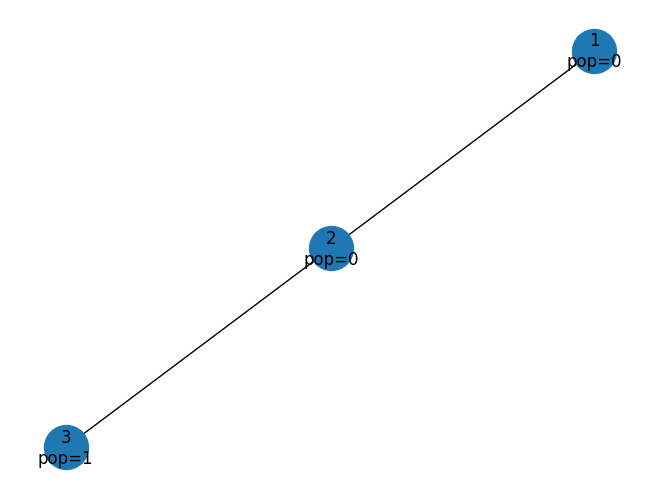

In [322]:
labels = {
    node: f"{node}\npop={g.nodes[node]['population']}"
    for node in g.nodes()
}

nx.draw(
    g,
    labels=labels,
    with_labels=True,
    node_size=1000
)

plt.show()



contracted 2 3


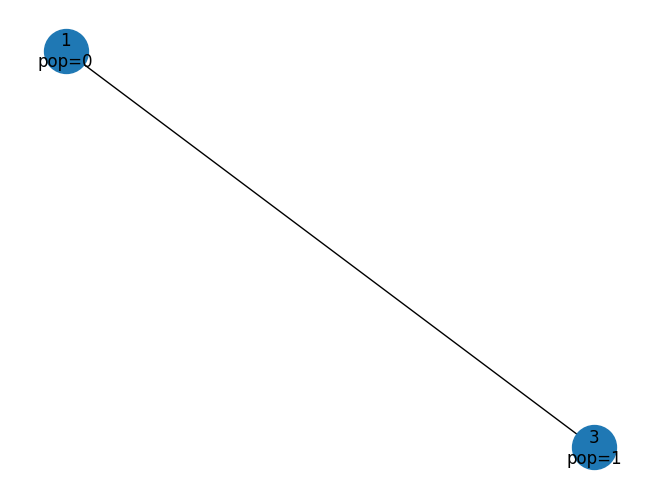

In [ ]:
#in principle if it iterates first over node 2, it will contract node 2 into node 3, and 
#then when it iterates over node 1, it will contract it into node 3 (which now is adjacent to node 1). 
#And therefore this error should only happen when it first iterates over node 1 followed by node 2
#but in practice no matter how I changed the order in which nodes were added it always looks like this
contract_zero_nodes(g)

labels = {
    node: f"{node}\npop={g.nodes[node]['population']}"
    for node in g.nodes()
}

nx.draw(
    g,
    labels=labels,
    with_labels=True,
    node_size=1000
)

plt.show()

Bug 2 (very much a toy example): The contract_nodes function contracts 0 nodes into their largest neighbours, if a 0 node has two or more neighbours with the same population it chooses which one to contract into solely based on the order in which edges were added which ideally you wouldnt want.

In [324]:
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4])

# add edges
G.add_edges_from([(2, 1), (2, 3), (2, 4)])

nx.set_node_attributes(
    G,
    {
        1: {"population": 2},
        2: {"population": 0},
        3: {"population": 2},
        4: {"population": 1},
    }
)

G_ = nx.Graph()
G_.add_nodes_from([1, 2, 3, 4])
G_.add_edges_from([(2, 3), (2, 4), (2, 1)])

nx.set_node_attributes(
    G_,
    {
        1: {"population": 2},
        2: {"population": 0},
        3: {"population": 2},
        4: {"population": 1},
    }
)

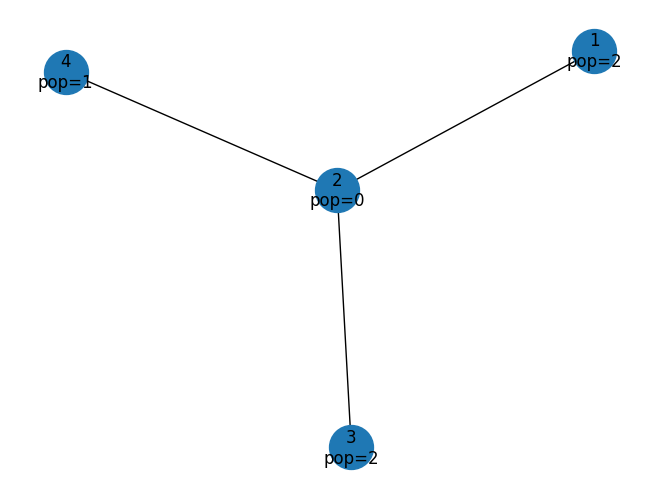

In [325]:
labels = {
    node: f"{node}\npop={G.nodes[node]['population']}"
    for node in G.nodes()
}

nx.draw(
    G,
    labels=labels,
    with_labels=True,
    node_size=1000
)

plt.show()

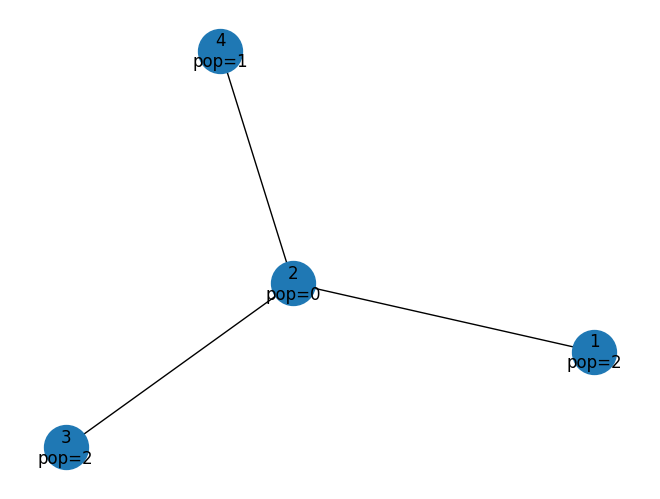

In [326]:
labels = {
    node: f"{node}\npop={G_.nodes[node]['population']}"
    for node in G_.nodes()
}

nx.draw(
    G_,
    labels=labels,
    with_labels=True,
    node_size=1000
)

plt.show()

G_ and G are identical graphs except in terms of the order in which the nodes were added, and therefore the order in which nx iterates over the nodes

contracted 2 1


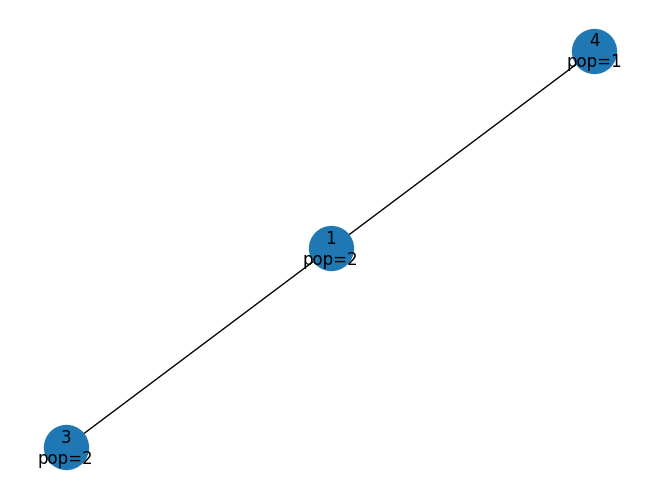

In [327]:
contract_zero_nodes(G)

labels = {
    node: f"{node}\npop={G.nodes[node]['population']}"
    for node in G.nodes()
}

nx.draw(
    G,
    labels=labels,
    with_labels=True,
    node_size=1000
)

plt.show()

contracted 2 3


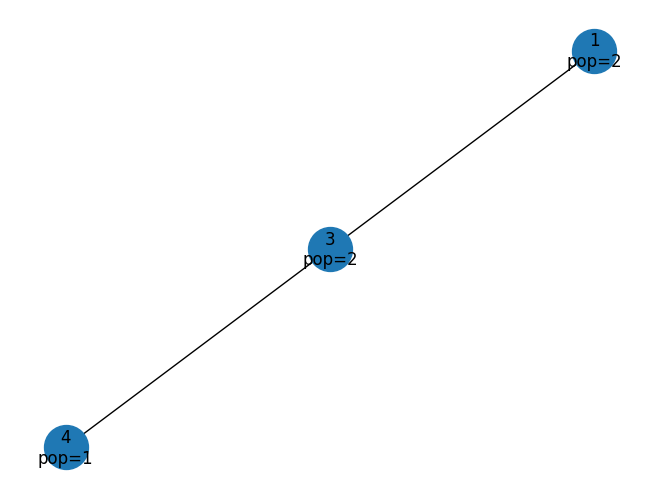

In [328]:
contract_zero_nodes(G_)

labels = {
    node: f"{node}\npop={G_.nodes[node]['population']}"
    for node in G_.nodes()
}

nx.draw(
    G_,
    labels=labels,
    with_labels=True,
    node_size=1000
)

plt.show()